In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# creating gates
from quantum_logical.gate_extender import Gate_extender, Convert_levels
dim = 2
N = 5
# creating the set of cnots (this will operate between the g and e levels)
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)
 
cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

# the x_gate needs to be made in a qutrit gate and will involve conversion 
x_gate = qt.Qobj([[0, 1],[1, 0]])
# z_gate = 1/np.sqrt(3) * qt.Qobj([[1, 0, 0],[0, 1, 0], [0, 0, -1]])

# hadamard gate
# hada = 1/np.sqrt(3) * qt.Qobj([[1, 1, 1],[1, -1/2 + np.sqrt(3)*1j/2, -1/2 - np.sqrt(3)*1j/2], [1, -1/2 - np.sqrt(3)*1j/2, -1/2 + np.sqrt(3)*1j/2]])
hada = qt.Qobj([[1/np.sqrt(2), 0, 1/np.sqrt(2)], [0, 1, 0], [1/np.sqrt(2), 0, -1/np.sqrt(2)]])


# new set of qutrit gates 
# extension of the gates into the qutrit space 
# need to make the gate extender take the individual qudit counts at every instance 
gate_extention = Gate_extender(num_qubits=1)
x_gate = gate_extention.qubit_to_qudit(gate=x_gate, from_dim=dim, to_dim=3)
gate_extention = Gate_extender(num_qubits=N)
cnot1 = gate_extention.qubit_to_qudit(gate=cnot1, from_dim=dim, to_dim=3)
cnot2 = gate_extention.qubit_to_qudit(gate=cnot2, from_dim=dim, to_dim=3)
cnot3 = gate_extention.qubit_to_qudit(gate=cnot3, from_dim=dim, to_dim=3)
cnot4 = gate_extention.qubit_to_qudit(gate=cnot4, from_dim=dim, to_dim=3)
cnot5 = gate_extention.qubit_to_qudit(gate=cnot5, from_dim=dim, to_dim=3)
cnot6 = gate_extention.qubit_to_qudit(gate=cnot6, from_dim=dim, to_dim=3)

# conversion of some of the gates into the qutrit space 
new_dim = 3
converter = Convert_levels(num_qubits=1)
x_gate = converter.level_conversion(levels=[0,2], dim=new_dim, gate=x_gate)
converter = Convert_levels(num_qubits=N)
cnot1= converter.level_conversion(levels=[1,2], dim=new_dim, gate=cnot1)
cnot2= converter.level_conversion(levels=[1,2], dim=new_dim, gate=cnot2)

x_layer = tensor(tensor([x_gate] * 3), tensor([qt.qeye(new_dim)] * 2))
hada_layer = tensor(tensor([hada] * 3), tensor([qt.qeye(new_dim)] * 2))

C:\Users\girgi\AppData\Local\Temp\ipykernel_6668\4234291739.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_6668\4234291739.py:7: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_6668\4234291739.py:9: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
fr

In [3]:
def neilson_fid(rho, sigma):
    return (((rho.sqrtm()) * sigma * (rho.sqrtm())).sqrtm()).tr()

In [4]:
# building the correction z_gate 
correction_x = qt.Qobj([[0, 1],[1, 0]])
gate_extention = Gate_extender(num_qubits=1)
correction_x = gate_extention.qubit_to_qudit(gate=correction_x, from_dim=dim, to_dim=3)
converter = Convert_levels(num_qubits=1)
correction_x = converter.level_conversion(levels=[1,2], dim=new_dim, gate=correction_x)

In [5]:
correction_z = (hada * correction_x * hada.dag())
correction_z

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]

In [6]:
# generating parameters and creating initial state
T1 = 5
T2 = 5

dim = new_dim
trotter_dt = .01

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qutrit")

In [7]:
# creating initial state
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 2)).unit(), tensor([basis(dim, 0)] * (N-1)))

rho0 = psi0 * psi0.dag()
encoded_rho = rho_encoded = hada_layer * cnot1 * rho0 * cnot1.dag()  * hada_layer.dag()

rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 

rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[3, 3, 3], [3, 3, 3]], shape = (27, 27), type = oper, isherm = True
Qobj data =
[[ 0.125  0.     0.125  0.     0.     0.    -0.125  0.    -0.125  0.
   0.     0.     0.     0.     0.     0.     0.     0.    -0.125  0.
  -0.125  0.     0.     0.     0.125  0.     0.125]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.125  0.     0.125  0.     0.     0.    -0.125  0.    -0.125  0.
   0.     0.     0.     0.     0.     0.     0.     0.    -0.125  0.
  -0.125  0.     0.     0.     0.125  0.     0.125]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0

instead of this averaging of the system build a system that can be used to measure logical error rate when performing the error correction since this level of averaging just wont give the results that you want to see

In [8]:
basis0 = qt.Qobj([[1],[0],[0]])
basis1 = qt.Qobj([[0],[1],[0]])
basis2 = qt.Qobj([[0],[0],[1]])
vector0 = hada * basis0
vector1 = hada * basis1
vector2 = hada * basis2
vectors = [vector0, vector1, vector2]
vectors = [tensor(i,j,k) for i in vectors for j in vectors for k in vectors]

In [9]:
vals = []
for vec in vectors:
    val = (vec.dag() * qt.ptrace(rho_encoded, [0,1,2]) * vec)[0][0][0]
    vals.append(val)
vals

[0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 (0.999999999999999+0j),
 0j,
 0j]

In [10]:
def sim_func(rho_encoded, T1, T2):

    # initializing Trotterization
    trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qutrit")
    
    # stored information
    states = []
    no_error_states = []

    # gate setups 
    gates = [[x_layer], [cnot3], [cnot4], [cnot5], [cnot6], [x_layer]]
    cnot_time = .5
    gate_times = [.025, cnot_time, cnot_time, cnot_time, cnot_time, .025]

    # stabilizer extraction
    rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
    rho_encoded1 = rho_encoded # point of reference when calculating fidelity 

    for i in range(len(gates)):
        rho_evo = trotter.apply(rho=rho_encoded, duration=gate_times[i], unitary=gates[i], errors=True)
        rho_evo_no_error = trotter.apply(rho=rho_encoded1, duration=gate_times[i], unitary=gates[i], errors=False)
        states.extend(rho_evo)
        no_error_states.extend(rho_evo_no_error)
        rho_encoded = rho_evo[-1]
        rho_encoded1 = rho_evo_no_error[-1]
        
    states.append(hada_layer * rho_encoded * hada_layer.dag())
    no_error_states.append(hada_layer * no_error_states[-1] * hada_layer.dag())

    # measurement

    # projection operators  
    proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]


    # look into how to get the projection results before moving forward be satisified with it 
    projection_results = [(states[-1] * proj[i]).tr() for i in range(len(proj))]

    # correction_operators
    r00 = qt.tensor([qt.qeye(dim)] * 5)
    r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), correction_z, qt.tensor([qt.qeye(dim)] * 2))
    r10 = qt.tensor(correction_z, qt.tensor([qt.qeye(dim)] * 4))
    r11 = qt.tensor(qt.qeye(dim), correction_z, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
    recovery_ops = [[r00], [r01], [r10], [r11]]

    rec = [[proj[0], r00],[proj[1], r01],[proj[2], r10],[proj[3], r11]]

    import random


    result = random.choices(rec, projection_results)
    # print(result)

    logical = sum([projection_results[i] for i in [0,2,3]]) # this is my metric for logical error 

    
    #  imperfect measurement 
    # projected_states = []
    # measurement_duration = .005
    # # for i in proj:
    # #     projected_state = trotter.apply(states[-1], duration=measurement_duration, unitary=[i], errors=False)
    # #     projected_states.append(projected_state)
    # projected_state = trotter.apply(states[-1], duration=measurement_duration, unitary=[result[0][0]], errors=False)
    # projected_states.append(projected_state)
    # no_error_projection = trotter.apply(no_error_states[-1], duration=measurement_duration, unitary=[tensor([qt.qeye(dim)] * N)], errors=False)
    # no_error_states.extend(no_error_projection)


    # recovery 
    # corrected_states = []
    # recovery_duration = .025
    # # for i in range(len(projected_states)):
    # #     corrected_state = trotter.apply(projected_states[i][-1], duration=recovery_duration, unitary=recovery_ops[i], errors=True)
    # #     corrected_states.append(corrected_state)
    # corrected_state = trotter.apply(projected_state[-1], duration=recovery_duration, unitary=[result[0][1]], errors=True)
    # no_error_states.append([no_error_states[-1]] * len(corrected_state))
    # states.extend(corrected_state)

    # for i in range(len(corrected_state)):
    #     combined_corrected_state = sum([projection_results[j] * corrected_states[j][i] for j in range(len(corrected_states))])
    #     states.append(combined_corrected_state)

    # total_time = recovery_duration + measurement_duration + sum(gate_times)

    return logical


In [11]:
iterations = 500
t1_list = np.linspace(.01, 40, iterations) 
log = []
for i in tqdm(range(iterations)):
    log.append(sim_func(rho_encoded=rho_encoded, T1=t1_list[i], T2=t1_list[i]))

100%|██████████| 500/500 [23:50<00:00,  2.86s/it]


Text(0.5, 1.0, 'Logical error rate vs Decoherence(t1=t2)')

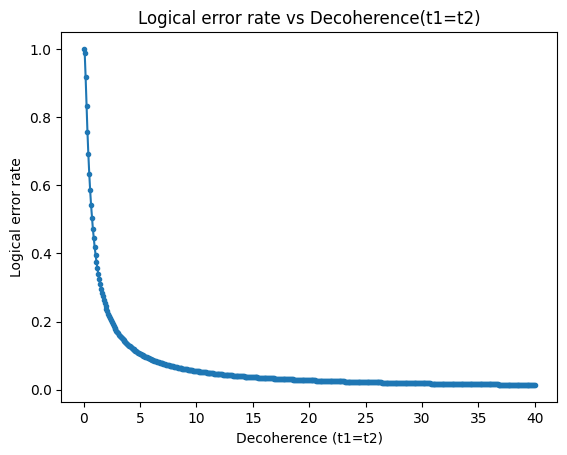

In [12]:
fig, ax = plt.subplots()
ax.plot(t1_list, log, marker=".")
ax.set_xlabel("Decoherence (t1=t2)")
ax.set_ylabel("Logical error rate")
ax.set_title("Logical error rate vs Decoherence(t1=t2)")